In [3]:

                                               # PashuAI
!pip install -q timm rich roboflow

import os, shutil, random, json, sys, time
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
console = Console()

# CONFIG

ROOT_RAW = Path("./datasets_raw")
ROOT_RAW.mkdir(exist_ok=True)
ROB_DIR = ROOT_RAW / "roboflow_bovine"

CLEAN_DIR = Path("./datasets_clean")
TRAIN_DIR = CLEAN_DIR / "train"
VAL_DIR   = CLEAN_DIR / "val"

IMG_SIZE = 224
BATCH_SIZE = 32
MIN_IMAGES_PER_BREED = 100
NUM_EPOCHS_SPECIES = 8
NUM_EPOCHS_BREED = 18
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RANDOM_SEED = 42

# keywords for species detection from folder names
COW_KEYWORDS = ["cow","cattle","gir","sahiwal","tharparkar","kankrej","ongole","nagori","red","hariana","deoni"]
BUFFALO_KEYWORDS = ["buffalo","murrah","mehsana","jaffarabadi","surti","nili","bhadawari","toda","pandharpuri","banni"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

ROBOFLOW_API_KEY = os.environ.get("ROBOFLOW_API_KEY", None)
if ROBOFLOW_API_KEY:
    console.print("[cyan]Roboflow API key found — attempting to download Roboflow Universe dataset...[/cyan]")
    try:
        from roboflow import Roboflow
        rf = Roboflow(api_key=ROBOFLOW_API_KEY)
        try:
            project = rf.workspace("shiv-q9erb").project("indian-bovine-breed-recognition-hen07")
            version = project.version(1)
            console.print("[cyan]Downloading Roboflow project: Indian Bovine Breed Recognition (attempt)[/cyan]")
            rf_path = version.download("folder", folder=str(ROB_DIR))
            console.print(f"[green]Roboflow dataset downloaded to {ROB_DIR}[/green]")
        except Exception as e:
            console.print(f"[yellow]Could not fetch project shiv-q9erb/indian-bovine-breed-recognition-hen07: {e}[/yellow]")
    except Exception as e:
        console.print(f"[yellow]Roboflow library error or API problem: {e}[/yellow]")
else:
    console.print("[yellow]No Roboflow API key found; skipping Roboflow download. To enable, set ROBOFLOW_API_KEY env var.[/yellow]")

# STEP 1: Kaggle + Mendeley downloads
KAGGLE_CONF = Path("/root/.kaggle/kaggle.json")
if not KAGGLE_CONF.exists() and Path("./kaggle.json").exists():
    os.makedirs("/root/.kaggle", exist_ok=True)
    shutil.copy("./kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

if Path("/root/.kaggle/kaggle.json").exists():
    console.print("[cyan]Kaggle credentials found — downloading standard datasets...[/cyan]")
    try:
        # core datasets
        !kaggle datasets download -d lukex9442/indian-bovine-breeds -p {ROOT_RAW} --force
        !unzip -q {ROOT_RAW}/indian-bovine-breeds.zip -d {ROOT_RAW}/indian_bovine

        !kaggle datasets download -d raghavdharwal/cows-and-buffalo-computer-vision-dataset -p {ROOT_RAW} --force
        !unzip -q {ROOT_RAW}/cows-and-buffalo-computer-vision-dataset.zip -d {ROOT_RAW}/cows_buffalo

        !kaggle datasets download -d anandkumarsahu09/cattle-breeds-dataset -p {ROOT_RAW} --force
        !unzip -q {ROOT_RAW}/cattle-breeds-dataset.zip -d {ROOT_RAW}/cattle_breeds

        # extra buffalo datasets
        !kaggle datasets download -d hsankesara/buffalo-images -p {ROOT_RAW} --force
        !unzip -q {ROOT_RAW}/buffalo-images.zip -d {ROOT_RAW}/buffalo_extra1

        !kaggle datasets download -d vasudevgupta7/indian-buffalo-breeds -p {ROOT_RAW} --force
        !unzip -q {ROOT_RAW}/indian-buffalo-breeds.zip -d {ROOT_RAW}/buffalo_extra2

        # Mendeley / other public zip
        !wget -q https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/vdgnxsm692-2.zip -O {ROOT_RAW}/buffalo_dataset.zip
        !unzip -q {ROOT_RAW}/buffalo_dataset.zip -d {ROOT_RAW}/buffalo_pak

        console.print("[green]Kaggle & public downloads attempted.[/green]")
    except Exception as e:
        console.print(f"[yellow]Kaggle download step failed or partially failed: {e}[/yellow]")
else:
    console.print("[yellow]No kaggle.json found in /content — skipping Kaggle downloads. If you want downloads, upload kaggle.json to Colab.[/yellow]")

# STEP 2: Scan raw folders into breed buckets

ROOT_SCAN_DIRS = [ROOT_RAW]
if ROB_DIR.exists():
    ROOT_SCAN_DIRS.append(ROB_DIR)

console.print("[cyan]Scanning raw directories for images...[/cyan]")
def is_image_file(p: Path): return p.suffix.lower() in {".jpg",".jpeg",".png",".webp"}
def detect_species_from_name(name: str):
    n = name.lower()
    if any(k in n for k in BUFFALO_KEYWORDS): return "buffaloes"
    if any(k in n for k in COW_KEYWORDS): return "cows"
    return None

breed_to_images = defaultdict(list)
total_images = 0
for root in ROOT_SCAN_DIRS:
    if not root.exists(): continue
    for p in root.rglob("*"):
        if p.is_file() and is_image_file(p):
            total_images += 1

            breed = p.parent.name.strip().replace(" ", "_")
            breed_to_images[breed].append(p)
console.print(f"Found {total_images} images across {len(breed_to_images)} candidate breed folders.")

# STEP 3: Prune & write datasets_clean (adaptive)

if CLEAN_DIR.exists(): shutil.rmtree(CLEAN_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

kept = []
dropped = []
for breed, imgs in breed_to_images.items():
    if len(imgs) < MIN_IMAGES_PER_BREED:
        dropped.append((breed, len(imgs)))
        continue
    sp = detect_species_from_name(breed)
    if sp is None:

        lower = breed.lower()
        if any(k in lower for k in BUFFALO_KEYWORDS):
            sp = "buffaloes"
        elif any(k in lower for k in COW_KEYWORDS):
            sp = "cows"
    if sp is None:
        dropped.append((breed, len(imgs)))
        continue
    kept.append((breed, len(imgs)))
    tr, va = train_test_split(imgs, test_size=0.2, random_state=RANDOM_SEED)
    tdir = TRAIN_DIR / sp / breed
    vdir = VAL_DIR / sp / breed
    tdir.mkdir(parents=True, exist_ok=True)
    vdir.mkdir(parents=True, exist_ok=True)
    for p in tr:
        try: shutil.copy(p, tdir / p.name)
        except: pass
    for p in va:
        try: shutil.copy(p, vdir / p.name)
        except: pass

console.print(f"[green]Organized datasets into {CLEAN_DIR}[/green]")
console.print(f"[cyan]Kept breeds ({len(kept)}):[/cyan] {[(b,n) for b,n in kept]}")
console.print(f"[red]Dropped breeds ({len(dropped)}):[/red] {[(b,n) for b,n in dropped[:40]]} {'...' if len(dropped)>40 else ''}")


if len(kept) == 0:
    console.print("[yellow]No breeds passed MIN_IMAGES_PER_BREED threshold. Lowering threshold to 50 and retrying...[/yellow]")
    MIN_IMAGES_PER_BREED = 60

    if CLEAN_DIR.exists(): shutil.rmtree(CLEAN_DIR)
    TRAIN_DIR.mkdir(parents=True, exist_ok=True)
    VAL_DIR.mkdir(parents=True, exist_ok=True)
    kept = []; dropped = []
    for breed, imgs in breed_to_images.items():
        if len(imgs) < MIN_IMAGES_PER_BREED:
            dropped.append((breed, len(imgs)))
            continue
        sp = detect_species_from_name(breed)
        if sp is None:
            lower = breed.lower()
            if any(k in lower for k in BUFFALO_KEYWORDS): sp = "buffaloes"
            elif any(k in lower for k in COW_KEYWORDS): sp = "cows"
        if sp is None:
            dropped.append((breed, len(imgs))); continue
        kept.append((breed, len(imgs)))
        tr, va = train_test_split(imgs, test_size=0.2, random_state=RANDOM_SEED)
        tdir = TRAIN_DIR / sp / breed; vdir = VAL_DIR / sp / breed
        tdir.mkdir(parents=True, exist_ok=True); vdir.mkdir(parents=True, exist_ok=True)
        for p in tr:
            try: shutil.copy(p, tdir / p.name)
            except: pass
        for p in va:
            try: shutil.copy(p, vdir / p.name)
            except: pass
    console.print(f"[green]After lowering threshold, kept {len(kept)} breeds.[/green]")

# STEP 4: Transforms

from torchvision.transforms import RandAugment
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# STEP 5: Build DataLoaders with WeightedRandomSampler for breed datasets

try:
    species_train_ds = ImageFolder(str(TRAIN_DIR), transform=train_transform)
    species_val_ds   = ImageFolder(str(VAL_DIR), transform=val_transform)
    species_train_loader = DataLoader(species_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    species_val_loader   = DataLoader(species_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    console.print(f"[green]Species classes: {species_train_ds.classes}[/green]")
except Exception as e:
    console.print(f"[red]Species ImageFolder error: {e}[/red]")
    raise

# Cow breed loaders
cow_train_root = TRAIN_DIR / "cows"
cow_val_root   = VAL_DIR / "cows"
if cow_train_root.exists():
    cow_train_ds = ImageFolder(str(cow_train_root), transform=train_transform)
    cow_val_ds   = ImageFolder(str(cow_val_root), transform=val_transform)
    cow_labels = [y for _,y in cow_train_ds.imgs]
    if len(cow_labels)>0:
        cow_class_counts = np.bincount(cow_labels)
        cow_weights = 1.0 / (cow_class_counts + 1e-6)
        cow_sample_weights = np.array([cow_weights[y] for y in cow_labels])
        cow_sampler = WeightedRandomSampler(torch.from_numpy(cow_sample_weights).double(), num_samples=len(cow_sample_weights), replacement=True)
        cow_train_loader = DataLoader(cow_train_ds, batch_size=BATCH_SIZE, sampler=cow_sampler, num_workers=4, pin_memory=True)
        cow_val_loader = DataLoader(cow_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    else:
        cow_train_loader = cow_val_loader = None
else:
    cow_train_loader = cow_val_loader = None

# Buffalo breed loaders
buff_train_root = TRAIN_DIR / "buffaloes"
buff_val_root   = VAL_DIR / "buffaloes"
if buff_train_root.exists():
    buff_train_ds = ImageFolder(str(buff_train_root), transform=train_transform)
    buff_val_ds   = ImageFolder(str(buff_val_root), transform=val_transform)
    buff_labels = [y for _,y in buff_train_ds.imgs]
    if len(buff_labels)>0:
        buff_class_counts = np.bincount(buff_labels)
        buff_weights = 1.0 / (buff_class_counts + 1e-6)
        buff_sample_weights = np.array([buff_weights[y] for y in buff_labels])
        buff_sampler = WeightedRandomSampler(torch.from_numpy(buff_sample_weights).double(), num_samples=len(buff_sample_weights), replacement=True)
        buff_train_loader = DataLoader(buff_train_ds, batch_size=BATCH_SIZE, sampler=buff_sampler, num_workers=4, pin_memory=True)
        buff_val_loader = DataLoader(buff_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    else:
        buff_train_loader = buff_val_loader = None
else:
    buff_train_loader = buff_val_loader = None

console.print("[green]Dataloaders ready.[/green]")

# STEP 6: Training helpers
def validate(model, loader):
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            pred = out.argmax(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total if total>0 else 0.0

def train_model_basic(model, train_loader, val_loader, epochs, lr=1e-4, save_path="model.pth"):
    model = model.to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best = 0.0
    for e in range(epochs):
        model.train()
        running_loss = 0.0; total = 0; correct = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs); loss = criterion(out, labels)
            opt.zero_grad(); loss.backward(); opt.step()
            running_loss += loss.item() * imgs.size(0)
            total += labels.size(0)
            correct += (out.argmax(1) == labels).sum().item()
        train_acc = 100.0 * correct / total if total>0 else 0.0
        val_acc = validate(model, val_loader)
        console.print(f"[Epoch {e+1}/{epochs}] train_acc={train_acc:.2f} val_acc={val_acc:.2f}")
        if val_acc > best:
            best = val_acc
            torch.save(model.state_dict(), save_path)
    return best

# STEP 7: Train 3 models

# Species model
console.print("[cyan]Training species model (cows vs buffaloes)...[/cyan]")
species_model = timm.create_model("resnet34", pretrained=True, num_classes=len(species_train_ds.classes))
species_best = train_model_basic(species_model, species_train_loader, species_val_loader, NUM_EPOCHS_SPECIES, lr=3e-4, save_path="species_model.pth")
console.print(f"[green]Species best val acc: {species_best:.2f}%[/green]")

# Cow breed model
if cow_train_loader is not None:
    console.print("[cyan]Training cow breed model...[/cyan]")
    cow_model = timm.create_model("tf_efficientnetv2_m", pretrained=True, num_classes=len(cow_train_loader.dataset.classes))
    cow_best = train_model_basic(cow_model, cow_train_loader, cow_val_loader, NUM_EPOCHS_BREED, lr=3e-4, save_path="cow_breed_model.pth")
    console.print(f"[green]Cow breed best val acc: {cow_best:.2f}%[/green]")
else:
    console.print("[yellow]No cow breed data found after pruning — skipping cow model.[/yellow]")

# Buffalo breed model
if buff_train_loader is not None:
    console.print("[cyan]Training buffalo breed model...[/cyan]")
    buff_model = timm.create_model("tf_efficientnetv2_m", pretrained=True, num_classes=len(buff_train_loader.dataset.classes))
    buff_best = train_model_basic(buff_model, buff_train_loader, buff_val_loader, NUM_EPOCHS_BREED, lr=3e-4, save_path="buffalo_breed_model.pth")
    console.print(f"[green]Buffalo breed best val acc: {buff_best:.2f}%[/green]")
else:
    console.print("[yellow]No buffalo breed data found after pruning — skipping buffalo model.[/yellow]")


# STEP 8: Inference helper (species + breed + info)

if Path("breed_info.json").exists():
    with open("breed_info.json","r") as f:
        breed_info = json.load(f)
else:
    breed_info = {}

def predict_full(img_path):
    img = Image.open(img_path).convert("RGB")
    x = val_transform(img).unsqueeze(0).to(DEVICE)

    # species
    s_model = timm.create_model("resnet34", pretrained=False, num_classes=len(species_train_ds.classes)).to(DEVICE)
    s_model.load_state_dict(torch.load("species_model.pth", map_location=DEVICE))
    s_model.eval()
    with torch.no_grad():
        out = s_model(x); sp_idx = out.argmax(1).item()
    species = species_train_ds.classes[sp_idx]

    # breed
    if species.lower().startswith("cow") and cow_train_loader is not None:
        b_model = timm.create_model("tf_efficientnetv2_m", pretrained=False, num_classes=len(cow_train_loader.dataset.classes)).to(DEVICE)
        b_model.load_state_dict(torch.load("cow_breed_model.pth", map_location=DEVICE)); b_model.eval()
        classes = cow_train_loader.dataset.classes
    elif buff_train_loader is not None:
        b_model = timm.create_model("tf_efficientnetv2_m", pretrained=False, num_classes=len(buff_train_loader.dataset.classes)).to(DEVICE)
        b_model.load_state_dict(torch.load("buffalo_breed_model.pth", map_location=DEVICE)); b_model.eval()
        classes = buff_train_loader.dataset.classes
    else:
        console.print("[red]Breed model not available for detected species[/red]")
        return {"species": species, "breed": None, "confidence": 0.0, "info": {}}

    with torch.no_grad():
        outb = b_model(x); prob = F.softmax(outb, dim=1); bi = prob.argmax(1).item(); conf = float(prob[0][bi].item())
    breed = classes[bi]
    info = breed_info.get(breed, {})
    # print
    table = Table(show_header=False, box=None)
    table.add_row("🐂 Species", species)
    table.add_row("🔖 Breed", f"{breed} ({conf*100:.2f}%)")
    table.add_row("📍 Region", info.get("region", "N/A"))
    table.add_row("⏳ Lifespan", info.get("lifespan", "N/A"))
    table.add_row("🥛 Milk Yield", info.get("milk_yield", "N/A"))
    table.add_row("🌾 Food", info.get("suitable_food", "N/A"))
    table.add_row("🦠 Diseases", ", ".join(info.get("diseases", [])))
    console.print(Panel(table, title="PashuAI Prediction", border_style="green"))
    return {"species": species, "breed": breed, "confidence": conf, "info": info}

console.print("[bold green]Pipeline complete. Use predict_full('path/to/image.jpg') to get results.[/bold green]")

No Roboflow API key found; skipping Roboflow download. To enable, set ROBOFLOW_API_KEY env var.

Kaggle credentials found — downloading standard datasets...

Dataset URL: https://www.kaggle.com/datasets/lukex9442/indian-bovine-breeds
License(s): CC0-1.0
 99% 2.82G/2.84G [00:57<00:00, 36.1MB/s]
100% 2.84G/2.84G [00:57<00:00, 53.2MB/s]
replace datasets_raw/indian_bovine/Indian_bovine_breeds/Alambadi/Alambadi_1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Dataset URL: https://www.kaggle.com/datasets/raghavdharwal/cows-and-buffalo-computer-vision-dataset
License(s): MIT
  0% 0.00/103M [00:00<?, ?B/s]
100% 103M/103M [00:00<00:00, 698MB/s]
replace datasets_raw/cows_buffalo/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Dataset URL: https://www.kaggle.com/datasets/anandkumarsahu09/cattle-breeds-dataset
License(s): CC0-1.0
  0% 0.00/20.9M [00:00<?, ?B/s]
100% 20.9M/20.9M [00:00<00:00, 689MB/s]
replace datasets_raw/cattle_breeds/Cattle Breeds/Ayrshire cattle/Ayrshirecattle0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/hsankesara/buffalo-images
unzip:  c

Kaggle & public downloads attempted.

Scanning raw directories for images...

...

[Epoch 16/18] train_acc=95.05 val_acc=81.71

[Epoch 17/18] train_acc=93.50 val_acc=84.15

[Epoch 18/18] train_acc=92.57 val_acc=81.71

Buffalo breed best val acc: 84.15%

Pipeline complete. Use predict_full('path/to/image.jpg') to get results.

Saving c4.webp to c4.webp


Preview for c4.webp

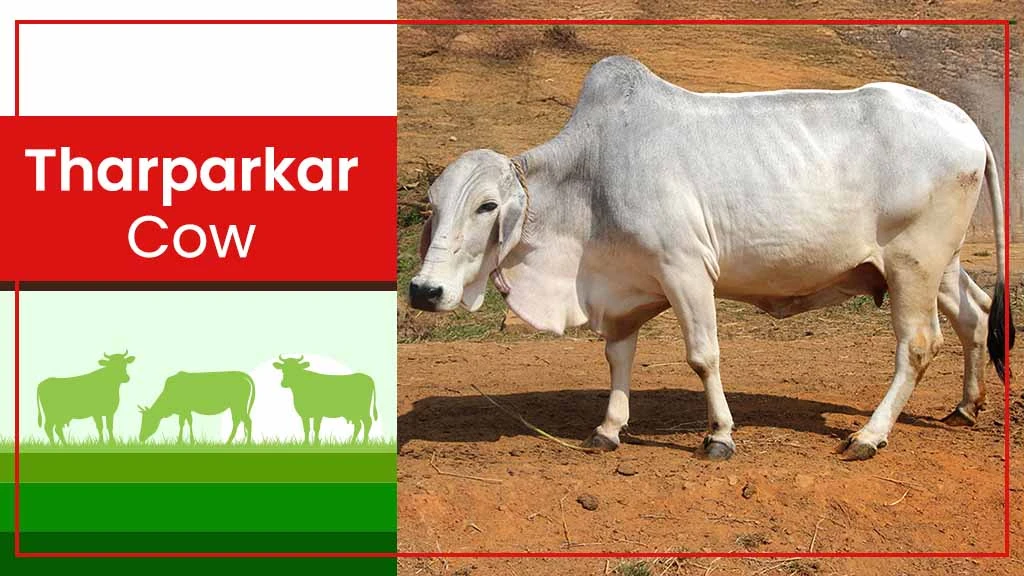

╭────────────────────────────────────────────── PashuAI Prediction ───────────────────────────────────────────────╮
│  🐂 Species     cows                                                                                            │
│  🔖 Breed       Tharparkar (42.33%)                                                                             │
│  📍 Region      Rajasthan (Thar desert)                                                                         │
│  ⏳ Lifespan    15–20 years                                                                                     │
│  🥛 Milk Yield  1800–2500 liters/year                                                                           │
│  🌾 Food        Drought-tolerant grasses, guar straw, bajra husk                                                │
│  🦠 Diseases    HS, FMD, Mastitis                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [25]:
from google.colab import files
from PIL import Image
from IPython.display import display
uploaded = files.upload()
for fn in uploaded.keys():
    try:
        img = Image.open(fn).convert("RGB")
        console.print(f"[cyan]Preview for {fn}[/cyan]")
        display(img)
        result = predict_full(fn)
    except Exception as e:
        console.print(f"[red]Prediction failed for {fn}: {e}[/red]")